# CIENCIA DE LA COMPUTACION
### Facultad de Ciencias 
---
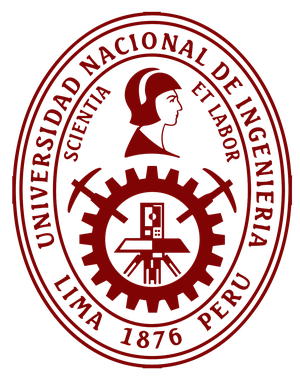
---

### Curso: Minería de Datos (CC442A)
### PC N°01: Condicionamiento Espectral y Estabilidad Numérica en el Preprocesamiento
---
---

### **Profesor:** Dr. Marco Antonio Alania Vicente
### **Estudiante:** César Omar López Arteaga

---
---

### 1. Introducción
El preprocesamiento de datos no es una mera limpieza empírica, sino un operador de transformación que actúa sobre el espectro de la matriz de datos $X \in \mathbb{R}^{n \times d}$. El dataset mal condicionado introduce inestabilidad, por lo que el objetivo de esta tarea es asegurar una matriz óptima algebraica y probabilísticamente.

### 2. Carga de Datos y Prevención de Data Leakage
Se carga el dataset de Arrhythmia.

El link del repositorio es: https://archive.ics.uci.edu/dataset/5/arrhythmia

Esta base de datos contiene 279 atributos, 206 de los cuales son de valores lineales y el resto nominales. 

Sobre el estudio de H. Altay Guvenir: "El objetivo es distinguir entre la presencia y ausencia de arritmias cardíacas y clasificarla en uno de los 16 grupos. La clase 01 se refiere a las clases de ECG 'normales' del 02 al 15, a diferentes clases de arritmia y la clase 16 al resto de las no clasificadas. Por el momento, existe un programa informático que realiza dicha clasificación. Sin embargo, existen diferencias entre la clasificación del cardiolog y el programa. Tomando los cardiologs como estándar de oro, buscamos minimizar esta diferencia mediante herramientas de aprendizaje automático."

### Descripción de las variables del dataset Arrhythmia

| Variable | Significado | Interpretación / valores |
|---|---|---|
| `age` (1) | Edad | Edad del paciente en años |
| `sex` (2) | Sexo | `0` = hombre, `1` = mujer |
| `height` (3) | Altura | Altura del paciente en centímetros |
| `weight` (4) | Peso | Peso del paciente en kilogramos |
| `qrs_duration` (5) | Duración QRS | Duración promedio del complejo QRS en milisegundos |
| `pr_interval` (6) | Intervalo P-R | Tiempo promedio entre el inicio de las ondas P y Q, en ms |
| `qt_interval` (7) | Intervalo Q-T | Tiempo promedio entre el inicio de Q y el final de T, en ms |
| `t_interval` (8) | Duración de onda T | Duración promedio de la onda T, en ms |
| `p_interval` (9) | Duración de onda P | Duración promedio de la onda P, en ms |
| `qrs_angle` (10) | Ángulo QRS | Ángulo del vector QRS en el plano frontal, en grados |
| `t_angle` (11) | Ángulo T | Ángulo del vector de la onda T, en grados |
| `p_angle` (12) | Ángulo P | Ángulo del vector de la onda P, en grados |
| `qrst_angle` (13) | Ángulo QRST | Ángulo del vector QRST en el plano frontal |
| `j_angle` (14) | Ángulo J | Ángulo del vector J en el plano frontal |
| `heart_rate` (15) | Frecuencia cardíaca | Número de latidos del corazón por minuto |
| `Variable_16` – `Variable_27` | Características de la derivación DI | Anchuras de Q, R, S, R', S'; número de deflexiones intrínsecas y características morfológicas de las ondas R, P y T |
| `Variable_28` – `Variable_39` | Características de la derivación DII | Mismas 12 características de forma y anchura medidas en DII |
| `Variable_40` – `Variable_51` | Características de la derivación DIII | Mismas 12 características medidas en DIII |
| `Variable_52` – `Variable_63` | Características de la derivación AVR | Mismas 12 características medidas en AVR |
| `Variable_64` – `Variable_75` | Características de la derivación AVL | Mismas 12 características medidas en AVL |
| `Variable_76` – `Variable_87` | Características de la derivación AVF | Mismas 12 características medidas en AVF |
| `Variable_88` – `Variable_99` | Características de la derivación V1 | Mismas 12 características medidas en V1 |
| `Variable_100` – `Variable_111` | Características de la derivación V2 | Mismas 12 características medidas en V2 |
| `Variable_112` – `Variable_123` | Características de la derivación V3 | Mismas 12 características medidas en V3 |
| `Variable_124` – `Variable_135` | Características de la derivación V4 | Mismas 12 características medidas en V4 |
| `Variable_136` – `Variable_147` | Características de la derivación V5 | Mismas 12 características medidas en V5 |
| `Variable_148` – `Variable_159` | Características de la derivación V6 | Mismas 12 características medidas en V6 |
| `Variable_160` – `Variable_169` | Amplitudes en DI | Amplitudes de las ondas JJ, Q, R, S, R', S', P y T; además de QRSA y QRSTA |
| `Variable_170` – `Variable_179` | Amplitudes en DII | Mismas 10 características de amplitud medidas en DII |
| `Variable_180` – `Variable_189` | Amplitudes en DIII | Mismas 10 características de amplitud medidas en DIII |
| `Variable_190` – `Variable_199` | Amplitudes en AVR | Mismas 10 características de amplitud medidas en AVR |
| `Variable_200` – `Variable_209` | Amplitudes en AVL | Mismas 10 características de amplitud medidas en AVL |
| `Variable_210` – `Variable_219` | Amplitudes en AVF | Mismas 10 características de amplitud medidas en AVF |
| `Variable_220` – `Variable_229` | Amplitudes en V1 | Mismas 10 características de amplitud medidas en V1 |
| `Variable_230` – `Variable_239` | Amplitudes en V2 | Mismas 10 características de amplitud medidas en V2 |
| `Variable_240` – `Variable_249` | Amplitudes en V3 | Mismas 10 características de amplitud medidas en V3 |
| `Variable_250` – `Variable_259` | Amplitudes en V4 | Mismas 10 características de amplitud medidas en V4 |
| `Variable_260` – `Variable_269` | Amplitudes en V5 | Mismas 10 características de amplitud medidas en V5 |
| `Variable_270` – `Variable_279` | Amplitudes en V6 | Mismas 10 características de amplitud medidas en V6 |
| `Clase` | **Variable objetivo** | Clase diagnóstica del ECG: `1` = normal, `2–15` = diferentes tipos de arritmia, `16` = otras arritmias |

### Variable objetivo: `Clase`

| Clase | Diagnóstico |
|---:|---|
| `1` | ECG normal |
| `2` | Cambios isquémicos / enfermedad arterial coronaria |
| `3` | Infarto de miocardio anterior antiguo |
| `4` | Infarto de miocardio inferior antiguo |
| `5` | Taquicardia sinusal |
| `6` | Bradicardia sinusal |
| `7` | Contracción ventricular prematura (PVC) |
| `8` | Contracción supraventricular prematura |
| `9` | Bloqueo de rama izquierda |
| `10` | Bloqueo de rama derecha |
| `11` | Bloqueo auriculoventricular de primer grado |
| `12` | Bloqueo auriculoventricular de segundo grado |
| `13` | Bloqueo auriculoventricular de tercer grado |
| `14` | Hipertrofia ventricular izquierda |
| `15` | Fibrilación o flutter auricular |
| `16` | Otras arritmias |

In [1]:
import numpy as np
import pandas as pd

# los valores faltantes estan representados por "?"
df = pd.read_csv(
    "arrhythmia.data",
    header=None,
    na_values="?"
)

print("Dimensión del dataset:")
print(df.shape)

print("\nPrimeras 10 observaciones:")
display(df.head(10))

Dimensión del dataset:
(452, 280)

Primeras 10 observaciones:


,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10
3,55,0,175,94,100,202,380,179,143,28,...,0.0,12.2,-2.2,0.0,0.0,0.4,2.6,34.6,61.6,1
4,75,0,190,80,88,181,360,177,103,-16,...,0.0,13.1,-3.6,0.0,0.0,-0.1,3.9,25.4,62.8,7
5,13,0,169,51,100,167,321,174,91,107,...,-0.6,12.2,-2.8,0.0,0.0,0.9,2.2,13.5,31.1,14
6,40,1,160,52,77,129,377,133,77,77,...,0.0,6.5,0.0,0.0,0.0,0.4,1.0,14.3,20.5,1
7,49,1,162,54,78,0,376,157,70,67,...,0.0,8.2,-1.9,0.0,0.0,0.1,0.5,15.8,19.8,1
8,44,0,168,56,84,118,354,160,63,61,...,0.0,7.0,-1.3,0.0,0.0,0.6,2.1,12.5,30.9,1
9,50,1,167,67,89,130,383,156,73,85,...,-0.6,10.8,-1.7,0.0,0.0,0.8,0.9,20.1,25.1,10


In [2]:
# Separar variables predictoras y variable objetivo
X_raw = df.iloc[:, :-1].copy()
y_raw = df.iloc[:, -1].copy()
#impresion de las primeras filas de la data
print("IMPRESION DE LA DATA X_raw:")
print(X_raw.head())
print("\nIMPRESION DE LA DATA y_raw:")
print(y_raw.head())
#exploracion del dataset
print("\nINFORMACION DEL DATASET:")
df.info()
print("\nVALORES FALTANTES:")
print(df.isnull().sum()[df.isnull().sum() > 0])


IMPRESION DE LA DATA X_raw:
   0    1    2    3    4    5    6    7    8    9    ...  269  270   271  272  \
0   75    0  190   80   91  193  371  174  121  -16  ... -0.3  0.0   9.0 -0.9   
1   56    1  165   64   81  174  401  149   39   25  ... -0.5  0.0   8.5  0.0   
2   54    0  172   95  138  163  386  185  102   96  ...  0.9  0.0   9.5 -2.4   
3   55    0  175   94  100  202  380  179  143   28  ...  0.1  0.0  12.2 -2.2   
4   75    0  190   80   88  181  360  177  103  -16  ... -0.4  0.0  13.1 -3.6   

   273  274  275  276   277   278  
0  0.0  0.0  0.9  2.9  23.3  49.4  
1  0.0  0.0  0.2  2.1  20.4  38.8  
2  0.0  0.0  0.3  3.4  12.3  49.0  
3  0.0  0.0  0.4  2.6  34.6  61.6  
4  0.0  0.0 -0.1  3.9  25.4  62.8  

[5 rows x 279 columns]

IMPRESION DE LA DATA y_raw:
0     8
1     6
2    10
3     1
4     7
Name: 279, dtype: int64

INFORMACION DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Columns: 280 entries, 0 to 279
dtypes: float64(125), i

Se identificado de la exploracion de datos:
 
* fila 10 tiene 8 datos faltantes
* fila 11 tiene 22 datos faltantes
* fila 12 tiene 1 dato faltante
* fila 13 tiene 376 datos faltantes
* fila 14 tiene 1 dato faltante

In [5]:
print("\n--- CALCULOS PREVIOS ---")
print("Tamñao de la matriz X:", df.shape)
nn,mm=df.shape
print("Numero de registros:", nn)
print("Numero de atributos:", mm)


--- CALCULOS PREVIOS ---
Tamñao de la matriz X: (452, 280)
Numero de registros: 452
Numero de atributos: 280


In [12]:
def calcular_vector_media(X):
    """
    Calcula el vector media de una matriz de datos.
    matriz_X: numpy array de forma (n, d)
    Retorna: numpy array de forma (1,(d,))
    """
    n,m=X.shape
    vect=np.zeros(m)
    for i in range(n): 
        vect+=X[i,:]
    vect/=n
    return np.sum(vect)/m,vect

# Prueba de la función
X = df.to_numpy()
print("X:", X)
print("X.shape:", X.shape)
mu,Vmed = calcular_vector_media(X)
print("Vector media calculado (Centro de gravedad):", Vmed)
print("Media de todos los datos calculado:", mu)

print("\nUsando libreria, vector media calculado (Centro de gravedad):", np.mean(X, axis=0 ))
print(f"Usando libreria, media de todos los datos: {np.mean(X)}")

X: [[ 75.    0.  190.  ...  23.3  49.4   8. ]
 [ 56.    1.  165.  ...  20.4  38.8   6. ]
 [ 54.    0.  172.  ...  12.3  49.   10. ]
 ...
 [ 36.    0.  166.  ... -44.2 -33.2   2. ]
 [ 32.    1.  155.  ...  25.   46.6   1. ]
 [ 78.    1.  160.  ...  21.3  32.8   1. ]]
X.shape: (452, 280)
Vector media calculado (Centro de gravedad): [ 4.64712389e+01  5.50884956e-01  1.66188053e+02  6.81703540e+01
  8.89203540e+01  1.55152655e+02  3.67207965e+02  1.69949115e+02
  9.00044248e+01  3.36769912e+01             nan             nan
             nan             nan             nan  5.62831858e+00
  5.16283186e+01  2.09203540e+01  1.41592920e-01  0.00000000e+00
  3.00353982e+01  2.21238938e-03  1.10619469e-02  1.10619469e-02
  4.42477876e-03  4.42477876e-03  8.84955752e-03  5.61946903e+00
  5.43362832e+01  2.05929204e+01  4.33628319e-01  1.50442478e-01
  3.16371681e+01  1.76991150e-02  2.87610619e-02  2.21238938e-03
  4.42477876e-03  4.42477876e-03  1.54867257e-02  1.60265487e+01
  4.19823009e+01  

y aplique un particionamiento estricto (Train/Test). Asegure que los parámetros estadísticos ($\mu, \sigma$) se calculen estrictamente en el set de entrenamiento.


In [ ]:

# TO-DO: Implementar Train/Test split utilizando exclusivamente NumPy/Pandas (Sin sklearn)
# X_train, X_test, y_train, y_test = ...

### 3. A) Análisis Estructural Inicial
Defina su dataset como una matriz $D \in \mathbb{R}^{n \times d}$. Evalúe el rango matricial $rank(D)$, el riesgo de singularidad a través del número de condición $\kappa(X^TX)$, y analice la distribución de los autovalores $\lambda_i$.

In [ ]:
# TO-DO: Cálculo del rango matricial empleando np.linalg.matrix_rank

# TO-DO: Matriz de covarianza y extracción de autovalores (np.linalg.eig o eigh)

# TO-DO: Cálculo del número de condición para X^T X (np.linalg.cond)


### 4. C) Tratamiento de Valores Faltantes
Identifique si los valores ausentes corresponden a un mecanismo MCAR, MAR o MNAR. Demuestre matemáticamente y empíricamente cómo la imputación por la media colapsa la varianza ($\sigma_{new}^2 = \frac{n}{n+m}\sigma_{obs}^2$), y construya su propio algoritmo de imputación iterativa multivariada (MICE).

In [ ]:
# TO-DO: Análisis de proporción y correlación de la matriz de nulidad (Missing Values)

# TO-DO: Demostración empírica del colapso de varianza tras imputar un atributo por su media

# TO-DO: Implementación base de imputación multivariada iterativa (solo NumPy/Pandas)


### 5. E) y B) Transformaciones Espaciales y Detección de Ruido
Aplique *Mean Centering* y demuestre la invarianza traslacional del rastro $tr(\Sigma)$. Posteriormente, detecte outliers multidimensionales implementando matemáticamente la Distancia de Mahalanobis $D_M(x) = \sqrt{(x-\mu)^T \Sigma^{-1} (x-\mu)}$.

In [ ]:
# TO-DO: Implementación manual de Mean Centering y Estandarización Z-score

# TO-DO: Cálculo de la matriz de covarianza inversa e iteración de la distancia de Mahalanobis

# TO-DO: Identificación de registros anómalos (Outliers) superando el límite estadístico


### 6. F) Análisis Crítico de Estabilidad
Redacte una discusión sobre cómo el preprocesamiento ha condicionado el espacio para evitar fugas de datos y asegurar un descenso de gradiente acelerado mediante el redondeo de las curvas de nivel del Hessiano.

**Respuesta del Estudiante:**
[Redacte su discusión técnica aquí]